In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [3]:
symbol_lst = ["SR", "CF", "OI", "AP", "CJ", "PF", "PK", "RM"]

In [4]:
init_money_lst = []
for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  首个交易日: {first_date}")
    print(f"  95分位数价格: {info['price_95th']:.2f}")
    print(f"  合约乘数: {info['contract_multiplier']}")
    print(f"  保证金率: {info['margin_rate']:.2%}")
    print(f"  10手保证金: {margin:,.2f}")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} ")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    print(f"  分均成交额: {activity['avg_turnover']:,.0f}")

    init_money_lst.append(int(margin / 0.4))

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.

品种: SR (白砂糖)
  首个交易日: 2021-02-01
  95分位数价格: 6063.00
  合约乘数: 10
  保证金率: 6.00%
  10手保证金: 36,378.00
  40%保证金所需本金: 90,945 
  分均持仓量: 369,957
  分均成交量: 663
  分均成交额: 36,988,125

品种: CF (棉花)
  首个交易日: 2021-02-01
  95分位数价格: 14885.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 52,097.50
  40%保证金所需本金: 130,244 
  分均持仓量: 590,983
  分均成交量: 815
  分均成交额: 57,040,952

品种: OI (菜籽油)
  首个交易日: 2021-02-01
  95分位数价格: 9985.00
  合约乘数: 10
  保证金率: 9.00%
  10手保证金: 89,865.00
  40%保证金所需本金: 224,662 
  分均持仓量: 261,760
  分均成交量: 893
  分均成交额: 85,021,866

品种: AP (苹果)
  首个交易日: 2021-02-01
  95分位数价格: 9731.00
  合约乘数: 10
  保证金率: 15.00%
  10手保证金: 145,965.00
  40%保证金所需本金: 364,912 
  分均持仓量: 107,286
  分均成交量: 443
  分均成交额: 38,083,192

品种: CJ (红枣)
  首个交易日: 2021-02-01
  95分位数价格: 11415.00
  合约乘数: 5
  保证金率: 10.00%
  10手保证金: 57,075.00
  40%保证金所需本金: 142,688 
  分均持仓量: 122,527
  分均成交量: 545
  分均成交额: 27,446,868

品种: PF (短

In [5]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'SR': 90945,
 'CF': 130243,
 'OI': 224662,
 'AP': 364912,
 'CJ': 142687,
 'PF': 58922,
 'PK': 83100,
 'RM': 67675}

In [6]:
weights = dict(zip(symbol_lst, [5_000_000 // x for x in init_money_lst]))
weights

{'SR': 54,
 'CF': 38,
 'OI': 22,
 'AP': 13,
 'CJ': 35,
 'PF': 84,
 'PK': 60,
 'RM': 73}

In [7]:
train_label = 5
rtn_mul = 1

bt_params = (0.9, 0.5, 10, 5*345)
train_end_date = '2025-01-01'

In [8]:
def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = f'/home/strategy_res/multi_train/models/{"_".join(symbol_lst)}'

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    # bt.load_factor(symbol, end_date=bt.window_end)

    factor_single = pd.read_feather(f'/home/strategy_res/multi_train/merged_df/{"_".join(symbol_lst)}.feather')
    factor_single = factor_single[factor_single['symbol'] == symbol].reset_index(drop=True)
    factor_single['hour'] = factor_single.datetime.dt.hour
    factor_single = factor_single[factor_single.datetime >= train_end_date]
    # factor_single = factor_single[factor_single.datetime.astype('datetime64[ns]').between(start_date, end_date)]
    
    factor_single = factor_single.sort_values('datetime').drop_duplicates('datetime', keep='last')
    factor_single = factor_single[~((factor_single['datetime'].dt.hour == 10) & (factor_single['datetime'].dt.minute == 30))]
    factor_single['datetime'] = pd.to_datetime(factor_single.datetime)
    bt.factor_single = factor_single.round(8) 

    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [9]:
merged_data_lst = []
for symbol in symbol_lst:
    print(f"\nProcessing {symbol}...")
    merged_data = run_res(symbol, bt_params)
    merged_data_lst.append(merged_data)


Processing SR...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/84955 [00:00<?, ?it/s]


Processing CF...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/84955 [00:00<?, ?it/s]


Processing OI...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


...

  0%|          | 0/84947 [00:00<?, ?it/s]


Processing PK...
trading_hours ['09:00-11:30', '13:30-15:00']


  0%|          | 0/57526 [00:00<?, ?it/s]


Processing RM...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/89902 [00:00<?, ?it/s]

In [10]:
# merged_data_lst = Parallel(n_jobs=1)(delayed(run_res)(symbol, bt_params)
#                                                    for symbol in symbol_lst)

In [11]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill().iloc[:-20]

In [12]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights)
merged_df_all

,SR,CF,OI,AP,CJ,PF,PK,RM
date,,,,,,,,
2025-01-02,4.911637e+06,4.962164e+06,5.298593e+06,4.795831e+06,4.957728e+06,4.919475e+06,4993944.522,4.953766e+06
2025-01-03,4.875946e+06,5.160927e+06,5.187185e+06,4.832910e+06,4.856438e+06,4.934333e+06,5011958.796,4.732635e+06
2025-01-06,5.074769e+06,5.169483e+06,5.236117e+06,4.943024e+06,4.827881e+06,5.131875e+06,4951779.513,4.815408e+06
2025-01-07,4.966596e+06,4.953407e+06,5.305101e+06,4.940594e+06,4.961513e+06,5.170141e+06,5011467.651,5.193175e+06
2025-01-08,4.896974e+06,4.924039e+06,5.268360e+06,5.061417e+06,4.917322e+06,5.230203e+06,4963339.794,5.212994e+06
...,...,...,...,...,...,...,...,...
2026-03-05,4.171484e+06,9.683957e+06,3.362611e+06,6.696908e+06,4.622937e+06,9.942202e+06,8761047.183,1.026655e+07
2026-03-06,4.184790e+06,9.592022e+06,3.373069e+06,6.866141e+06,4.702377e+06,9.746076e+06,8731385.376,9.900017e+06
2026-03-09,4.051932e+06,9.456607e+06,2.786606e+06,6.866141e+06,4.702377e+06,9.746076e+06,8731385.376,1.069203e+07


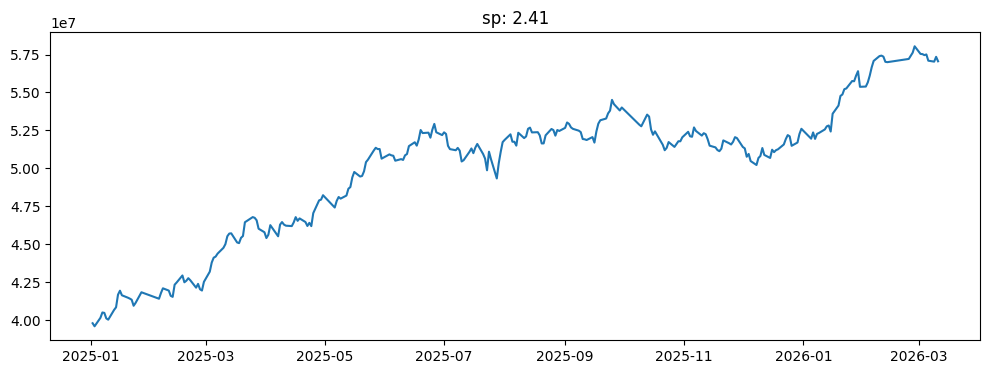

In [13]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

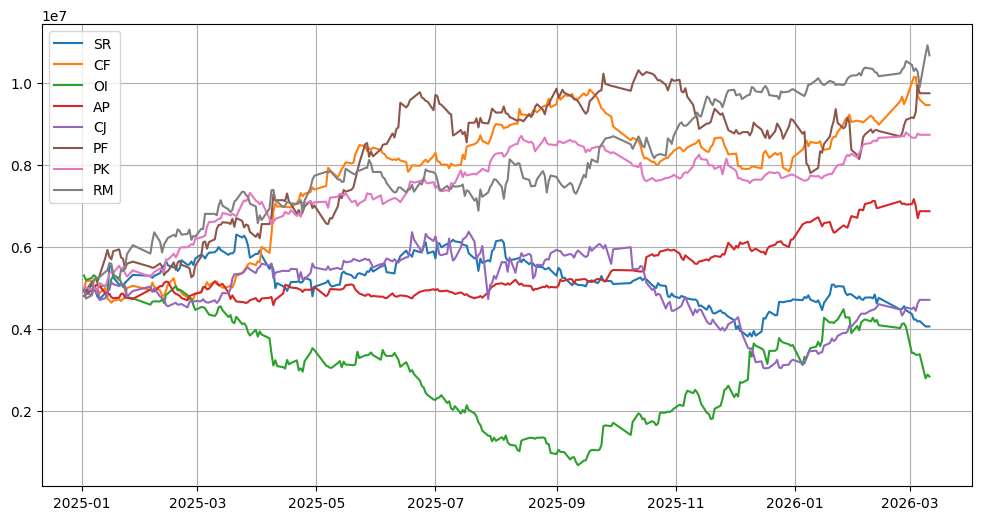

In [14]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [15]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res

,SR,CF,OI,AP,CJ,PF,PK,RM
多头(+1) 数量,17713,18922,17297,10115,10679,17912,11875,17302
空头(-1) 数量,20923,18871,22674,12653,11498,19650,11202,21071
空仓(0) 数量,46321,47164,51046,34760,35351,47387,34451,51531
多头占比,20.85%,22.27%,19.00%,17.58%,18.56%,21.09%,20.64%,19.24%
空头占比,24.63%,22.21%,24.91%,21.99%,19.99%,23.13%,19.47%,23.44%
空仓占比,54.52%,55.52%,56.08%,60.42%,61.45%,55.78%,59.89%,57.32%
交易日数量,284,284,306,282,282,284,282,302
总收益(非年化%),-10.01,91.03,-50.90,44.74,-5.84,101.64,75.12,147.93
总交易次数（开平算一次）,2930,3708,2796,2054,2922,3710,3644,2498
日均交易次数（开平算一次）,10.32,13.05,9.14,7.28,10.36,13.06,12.92,8.27
